In [1]:
from utils import paths
import pypsa
import numpy as np

n = pypsa.Network(paths.CLUSTERED_NETWORK)

import geopandas as gpd
shapes = gpd.read_file(paths.COUNTRY_SHAPES)

c:\Users\natha\Desktop\EPFL\Power_GSP\pypsa-eur\.pixi\envs\dev\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'PyPSA-Eur (osm vlatest)' has buses, carriers, lines, links, shapes
c:\Users\natha\Desktop\EPFL\Power_GSP\pypsa-eur\.pixi\envs\dev\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Text(0.5, 1.0, 'Réseau haute tension de PyPSA-Eur')

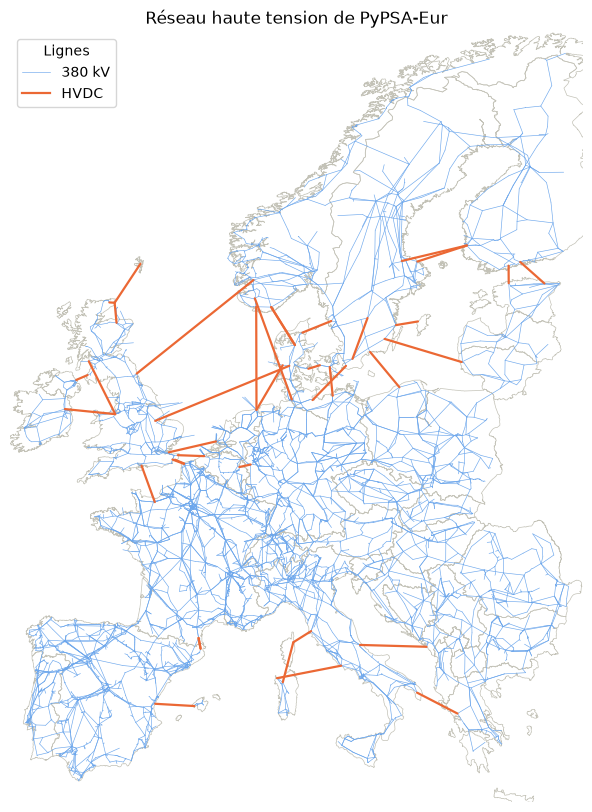

In [2]:
from utils.plotting import draw_network
import matplotlib.pyplot as plt  

fig, ax = plt.subplots(figsize=(15, 10))
draw_network(ax, n, shapes)
ax.set_title("Réseau haute tension de PyPSA-Eur")

Text(0.5, 1.0, 'Réseau haute tension de PyPSA-Eur')

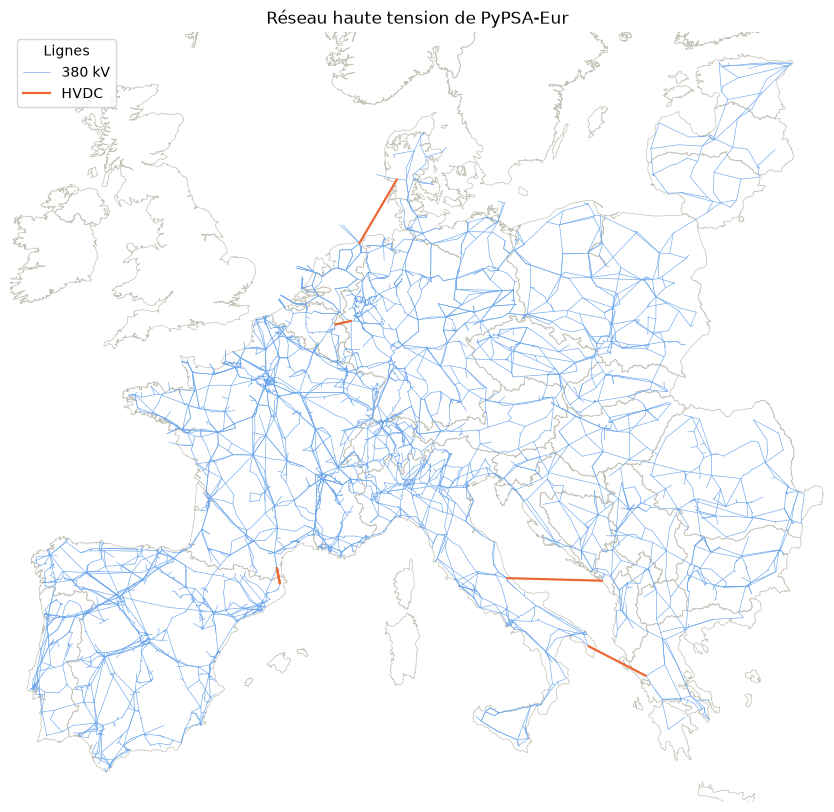

In [3]:
from utils.network import remove_non_synchronous_areas

n = remove_non_synchronous_areas(n)
fig, ax = plt.subplots(figsize=(15, 10))
draw_network(ax, n, shapes)
ax.set_title("Réseau haute tension de PyPSA-Eur")

In [4]:
from utils.grid import Grid

# Réseau synchrone continental + inerties des centrales
grid = Grid(paths.CLUSTERED_NETWORK, paths.POWERPLANTS)
grid

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'PyPSA-Eur (osm vlatest)' has buses, carriers, lines, links, shapes


4978 centrales hors du réseau ignorées (250 GW)


In [5]:
# Get graph Laplacian and its eigenvalues
L = grid.L.toarray()
eigenvalues, eigenvectors = np.linalg.eigh(L)

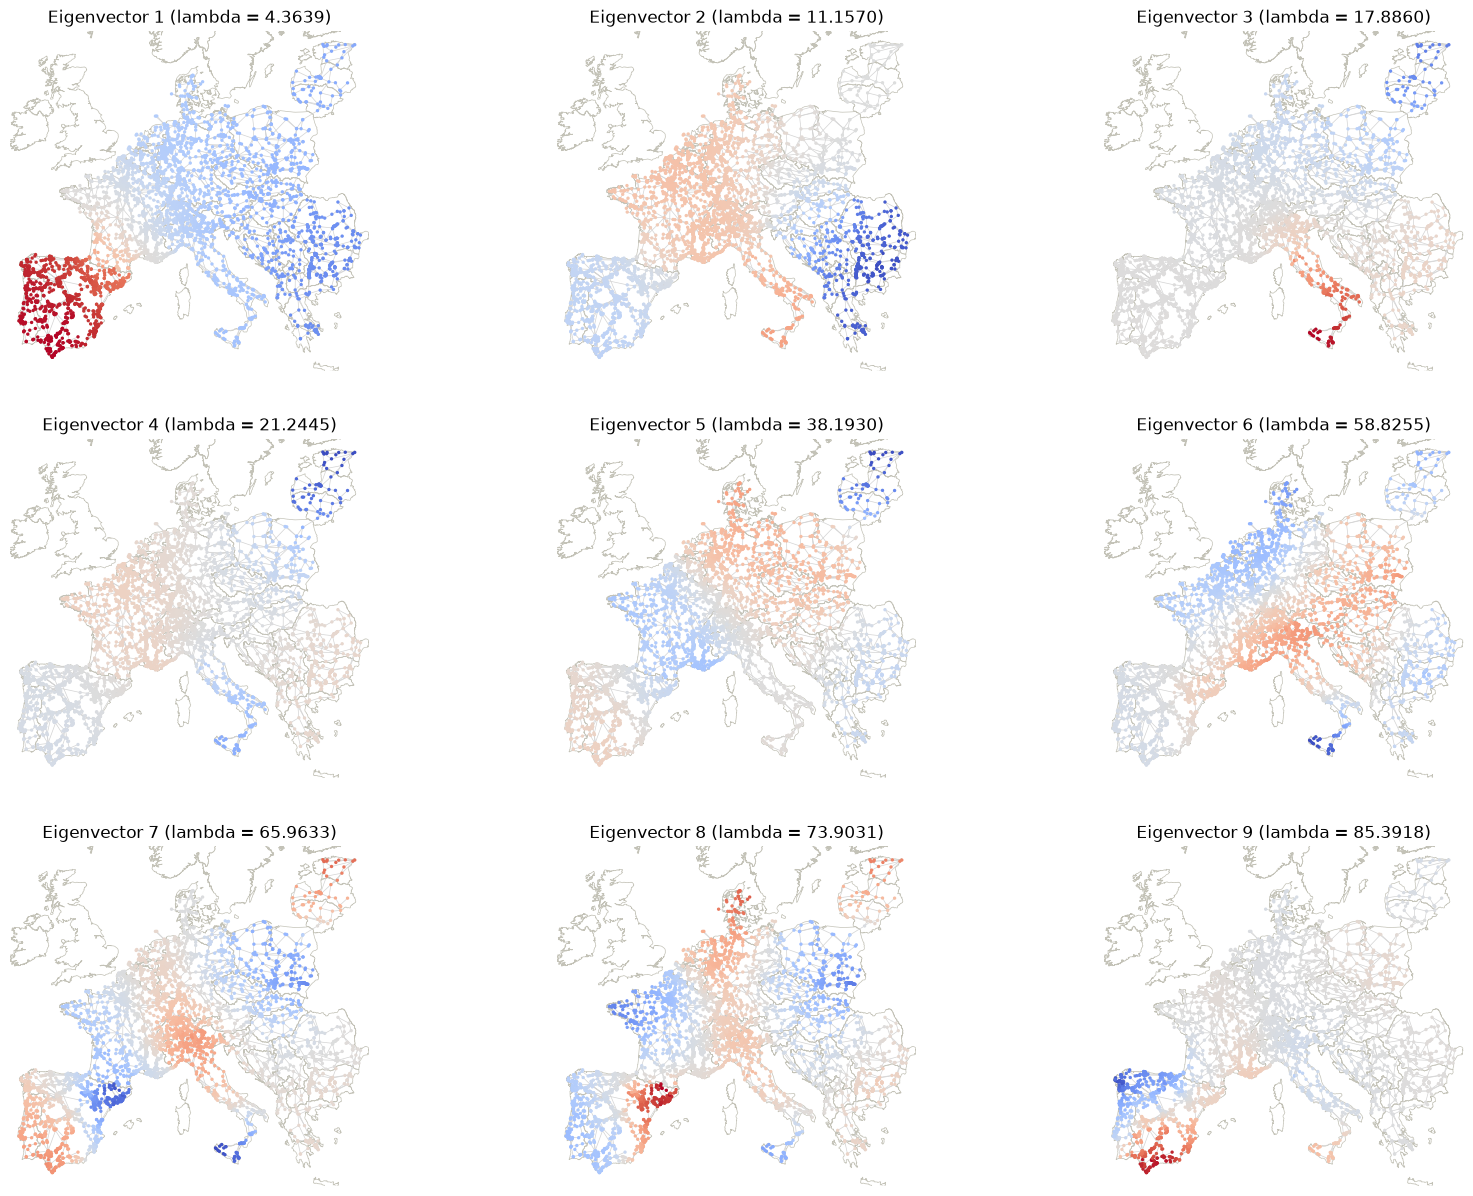

In [6]:
from utils.plotting import draw_graph_signals

# Subplots for the first 9 eigenvectors
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
for i in range(9):
    ax = axes[i // 3, i % 3]
    draw_graph_signals(ax, grid, eigenvectors[:, i+1], shapes)
    ax.set_title(f"Eigenvector {i+1} (lambda = {eigenvalues[i+1]:.4f})")

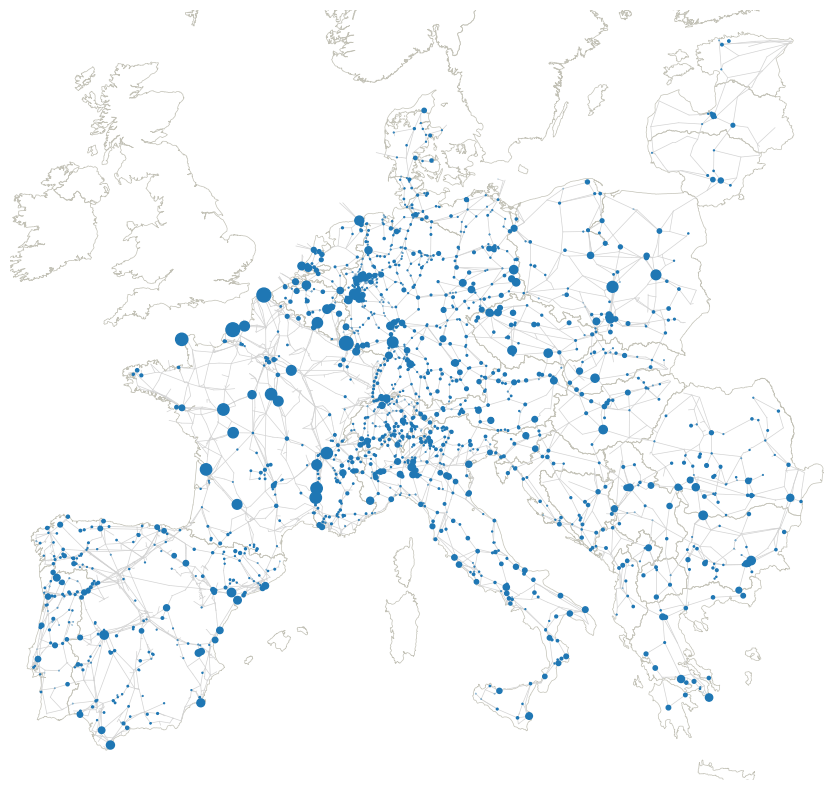

In [7]:
from utils.plotting import draw_graph_signals_area
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(15, 10))
draw_graph_signals_area(ax, grid, grid.buses.E, shapes)

Premiers modes inter-zones : [0.223 0.29  0.352] Hz
ΔP total : -1430 MW


Text(0.5, 0.98, "Écart de fréquence au centre d'inertie (mHz)")

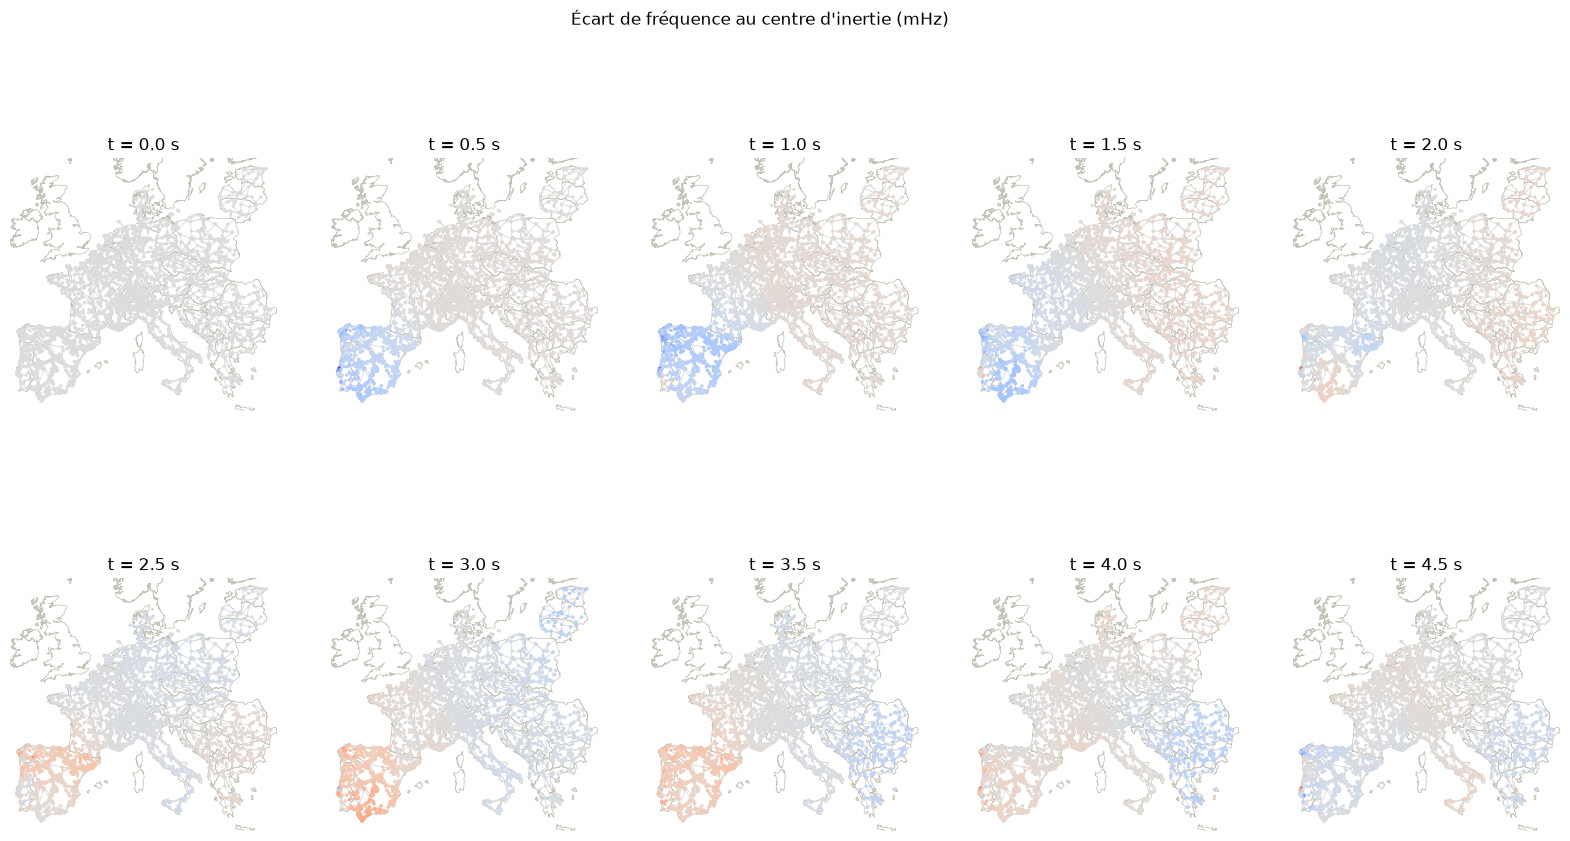

In [8]:
from matplotlib.colors import CenteredNorm

# Équation d'oscillation sans amortissement M δ'' + L δ = ΔP, solution modale exacte
print(f"Premiers modes inter-zones : {np.round(grid.frequencies[1:4], 3)} Hz")

# Perte de production de 10 MW sur chaque nœud à l'ouest de -8° (Portugal, Galice)
Delta_P = np.where(grid.buses.x < -8, -10.0, 0.0)
print(f"ΔP total : {Delta_P.sum():.0f} MW")

# Une période du premier mode inter-zones (~0.22 Hz -> ~4.5 s)
t = np.linspace(0, 4.5, 10)
delta, freq = grid.step_response(Delta_P, t)

# Écart à la fréquence du centre d'inertie : on retire la dérive commune pour voir les oscillations entre zones
m = grid.M.diagonal()
f_coi = m @ freq.to_numpy() / m.sum()
freq_rel = freq - f_coi

# Même échelle de couleurs pour tous les instants
norm = CenteredNorm(halfrange=np.abs(freq_rel.to_numpy()).max() * 1e3)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
for i, ax in enumerate(axes.flat):
    draw_graph_signals(ax, grid, freq_rel.iloc[:, i] * 1e3, shapes, norm=norm)
    ax.set_title(f"t = {t[i]:.1f} s")
fig.suptitle("Écart de fréquence au centre d'inertie (mHz)")

Text(0.5, 1.0, "RoCoF du centre d'inertie : -15.0 mHz/s")

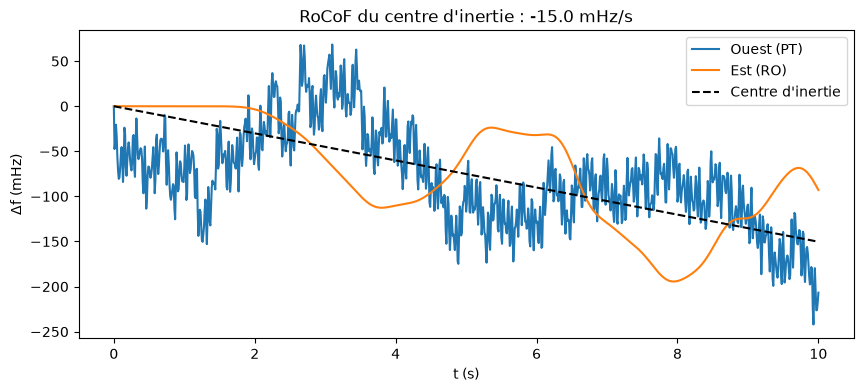

In [9]:
# Évolution temporelle : centre d'inertie et nœuds aux deux extrémités du réseau
t_fine = np.linspace(0, 10, 1001)
_, freq_fine = grid.step_response(Delta_P, t_fine)
f_coi_fine = m @ freq_fine.to_numpy() / m.sum()

west, east = grid.buses.x.idxmin(), grid.buses.x.idxmax()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_fine, freq_fine.loc[west] * 1e3, label=f"Ouest ({grid.buses.country[west]})")
ax.plot(t_fine, freq_fine.loc[east] * 1e3, label=f"Est ({grid.buses.country[east]})")
ax.plot(t_fine, f_coi_fine * 1e3, "k--", label="Centre d'inertie")
ax.set_xlabel("t (s)")
ax.set_ylabel("Δf (mHz)")
ax.legend()
ax.set_title(f"RoCoF du centre d'inertie : {f_coi_fine[-1] / t_fine[-1] * 1e3:.1f} mHz/s")